# GenAI for Time Series — Amazon Chronos and Chronos 2

A foundation model for forecasting. It has never seen your series and it forecasts it anyway.

| | |
|---|---|
| **Course section** | GenAI for Time Series: Amazon Chronos |
| **Data** | Beijing multi-site air quality, loaded through the `tsdb` library |
| **Libraries** | `chronos-forecasting`, `tsdb`, `torch` |
| **Runs on** | GPU strongly recommended |

> **Turn the GPU on before you run this.** In Colab: `Runtime → Change runtime type → T4 GPU`.
> On CPU these cells finish eventually, but not in a sitting.

> **Environment.** Chronos needs its own environment: `chronos-forecasting` installs from git and
> pins `torch==2.6.0`. Install from the `requirements.txt` in this folder.

## Roadmap

1. Libraries and data
2. Exploratory analysis
3. The original Chronos model
4. **Chronos 2**
   - Univariate, no covariates
   - Univariate with past covariates
5. Multiple stations with past covariates
6. Cross-validation
7. Predict the future

## Zero-shot forecasting

Chronos was trained on a very large collection of time series, and it treats forecasting the way a
language model treats text: the series is tokenised, and the model predicts what comes next.

The practical consequence is that there is no training step. You hand it a history and it returns a
forecast, with prediction intervals, immediately.

That makes it the fastest strong baseline available. Run Chronos before you spend two days tuning an
LSTM, and you will at least know what you are trying to beat.

## Where it still loses

A model tuned on your specific series, with your covariates, can beat a zero-shot foundation model.
Section 6 is where you find out whether yours does. Fine-tuning is covered in the AutoGluon section.

---

Part of **[Master Time Series Analysis and Forecasting with Python](https://www.udemy.com/course/forecasting-python/?referralCode=63045C9CC807EB1EBD9A)** · [All notebooks](https://github.com/diogoalvesderesende/time-series-forecasting-python)

# Libraries and Data

In [1]:
# Install the chronos library and time series database
!pip install -q git+https://github.com/amazon-science/chronos-forecasting.git
!pip install -q tsdb

  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done


In [2]:
# Libraries
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.graphics.tsaplots import month_plot, quarter_plot
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.seasonal import seasonal_decompose
from sklearn.metrics import mean_absolute_error, root_mean_squared_error, mean_absolute_percentage_error
import numpy as np
from sklearn.model_selection import ParameterGrid

import tsdb
from chronos import ChronosPipeline, BaseChronosPipeline, Chronos2Pipeline
from datetime  import datetime
import torch

2026-07-25 06:48:03 [WARNING]: ‼️ PyPOTS Ecosystem configuration file does not exist.
2026-07-25 06:48:03 [INFO]: Wrote new configs to config.ini successfully.
2026-07-25 06:48:03 [INFO]: 💫 Initialized PyPOTS Ecosystem configuration file /root/.pypots/config.ini successfully.


In [3]:
# Load the Data from TSDB library
# Air quality data of sites in beijing
df = pd.DataFrame(tsdb.load('beijing_multisite_air_quality')['X'])
df.head()

2026-07-25 06:48:34 [INFO]: You're using dataset beijing_multisite_air_quality, please cite it properly in your work. You can find its reference information at the below link: 
https://github.com/WenjieDu/TSDB/tree/main/dataset_profiles/beijing_multisite_air_quality
2026-07-25 06:48:34 [INFO]: Start downloading...
2026-07-25 06:48:35 [INFO]: Successfully downloaded data to /tmp/tmpggzv3zdp/PRSA2017_Data_20130301-20170228.zip
2026-07-25 06:48:35 [INFO]: Successfully extracted data to /root/.pypots/tsdb/beijing_multisite_air_quality
2026-07-25 06:48:35 [INFO]: Reading /root/.pypots/tsdb/beijing_multisite_air_quality/PRSA_Data_20130301-20170228/PRSA_Data_Changping_20130301-20170228.csv, data shape (35064, 18)
2026-07-25 06:48:35 [INFO]: Reading /root/.pypots/tsdb/beijing_multisite_air_quality/PRSA_Data_20130301-20170228/PRSA_Data_Huairou_20130301-20170228.csv, data shape (35064, 18)
2026-07-25 06:48:35 [INFO]: Reading /root/.pypots/tsdb/beijing_multisite_air_quality/PRSA_Data_20130301-201

,No,year,month,day,hour,PM2.5,PM10,SO2,NO2,CO,O3,TEMP,PRES,DEWP,RAIN,wd,WSPM,station
0,1,2013,3,1,0,3.0,6.0,13.0,7.0,300.0,85.0,-2.3,1020.8,-19.7,0.0,E,0.5,Changping
1,2,2013,3,1,1,3.0,3.0,6.0,6.0,300.0,85.0,-2.5,1021.3,-19.0,0.0,ENE,0.7,Changping
2,3,2013,3,1,2,3.0,3.0,22.0,13.0,400.0,74.0,-3.0,1021.3,-19.9,0.0,ENE,0.2,Changping
3,4,2013,3,1,3,3.0,6.0,12.0,8.0,300.0,81.0,-3.6,1021.8,-19.1,0.0,NNE,1.0,Changping
4,5,2013,3,1,4,3.0,3.0,14.0,8.0,300.0,81.0,-3.5,1022.3,-19.4,0.0,N,2.1,Changping


In [4]:
# Display information about the DataFrame, including data types and non-null counts
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 420768 entries, 0 to 35063
Data columns (total 18 columns):
 #   Column   Non-Null Count   Dtype  
---  ------   --------------   -----  
 0   No       420768 non-null  int64  
 1   year     420768 non-null  int64  
 2   month    420768 non-null  int64  
 3   day      420768 non-null  int64  
 4   hour     420768 non-null  int64  
 5   PM2.5    412029 non-null  float64
 6   PM10     414319 non-null  float64
 7   SO2      411747 non-null  float64
 8   NO2      408652 non-null  float64
 9   CO       400067 non-null  float64
 10  O3       407491 non-null  float64
 11  TEMP     420370 non-null  float64
 12  PRES     420375 non-null  float64
 13  DEWP     420365 non-null  float64
 14  RAIN     420378 non-null  float64
 15  wd       418946 non-null  object 
 16  WSPM     420450 non-null  float64
 17  station  420768 non-null  object 
dtypes: float64(11), int64(5), object(2)
memory usage: 61.0+ MB


In [5]:
# Rename the 'TEMP' column as 'y'
df = df.rename(columns = {'TEMP': 'y'})
df.head()

,No,year,month,day,hour,PM2.5,PM10,SO2,NO2,CO,O3,y,PRES,DEWP,RAIN,wd,WSPM,station
0,1,2013,3,1,0,3.0,6.0,13.0,7.0,300.0,85.0,-2.3,1020.8,-19.7,0.0,E,0.5,Changping
1,2,2013,3,1,1,3.0,3.0,6.0,6.0,300.0,85.0,-2.5,1021.3,-19.0,0.0,ENE,0.7,Changping
2,3,2013,3,1,2,3.0,3.0,22.0,13.0,400.0,74.0,-3.0,1021.3,-19.9,0.0,ENE,0.2,Changping
3,4,2013,3,1,3,3.0,6.0,12.0,8.0,300.0,81.0,-3.6,1021.8,-19.1,0.0,NNE,1.0,Changping
4,5,2013,3,1,4,3.0,3.0,14.0,8.0,300.0,81.0,-3.5,1022.3,-19.4,0.0,N,2.1,Changping


In [6]:
# Function to create a datetime variable from the year, month, day and hour
def clean_datetime(df):
  dttime = str(df['year']) + "-" + str(df['month']) + "-" + str(df['day']) + " " + str(df['hour']) + ":00:00"
  return datetime.strptime(dttime, '%Y-%m-%d %H:%M:%S')

# Apply the function
df['ds'] = df.apply(clean_datetime, axis = 1)
df.head()

,No,year,month,day,hour,PM2.5,PM10,SO2,NO2,CO,O3,y,PRES,DEWP,RAIN,wd,WSPM,station,ds
0,1,2013,3,1,0,3.0,6.0,13.0,7.0,300.0,85.0,-2.3,1020.8,-19.7,0.0,E,0.5,Changping,2013-03-01 00:00:00
1,2,2013,3,1,1,3.0,3.0,6.0,6.0,300.0,85.0,-2.5,1021.3,-19.0,0.0,ENE,0.7,Changping,2013-03-01 01:00:00
2,3,2013,3,1,2,3.0,3.0,22.0,13.0,400.0,74.0,-3.0,1021.3,-19.9,0.0,ENE,0.2,Changping,2013-03-01 02:00:00
3,4,2013,3,1,3,3.0,6.0,12.0,8.0,300.0,81.0,-3.6,1021.8,-19.1,0.0,NNE,1.0,Changping,2013-03-01 03:00:00
4,5,2013,3,1,4,3.0,3.0,14.0,8.0,300.0,81.0,-3.5,1022.3,-19.4,0.0,N,2.1,Changping,2013-03-01 04:00:00


In [7]:
# Set the ds in the index
df = df.set_index('ds')
df.head()

,No,year,month,day,hour,PM2.5,PM10,SO2,NO2,CO,O3,y,PRES,DEWP,RAIN,wd,WSPM,station
ds,,,,,,,,,,,,,,,,,,
2013-03-01 00:00:00,1,2013,3,1,0,3.0,6.0,13.0,7.0,300.0,85.0,-2.3,1020.8,-19.7,0.0,E,0.5,Changping
2013-03-01 01:00:00,2,2013,3,1,1,3.0,3.0,6.0,6.0,300.0,85.0,-2.5,1021.3,-19.0,0.0,ENE,0.7,Changping
2013-03-01 02:00:00,3,2013,3,1,2,3.0,3.0,22.0,13.0,400.0,74.0,-3.0,1021.3,-19.9,0.0,ENE,0.2,Changping
2013-03-01 03:00:00,4,2013,3,1,3,3.0,6.0,12.0,8.0,300.0,81.0,-3.6,1021.8,-19.1,0.0,NNE,1.0,Changping
2013-03-01 04:00:00,5,2013,3,1,4,3.0,3.0,14.0,8.0,300.0,81.0,-3.5,1022.3,-19.4,0.0,N,2.1,Changping


In [8]:
# Zooming in on Wanliu
y = df.loc[df["station"] == "Wanliu"]["y"]
y.head()

,y
ds,
2013-03-01 00:00:00,-0.7
2013-03-01 01:00:00,-1.1
2013-03-01 02:00:00,-1.1
2013-03-01 03:00:00,-1.4
2013-03-01 04:00:00,-2.0


In [9]:
# Setting the Frequency
y = y.asfreq("h")

# Exploratory Data Analysis

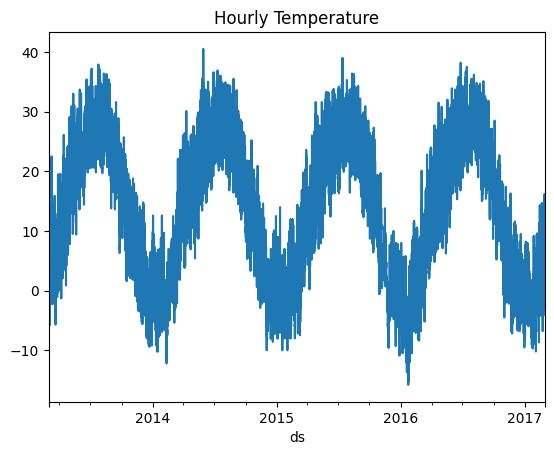

In [10]:
# Plot the hourly temperature data
y.plot(title = 'Hourly Temperature')
plt.show()

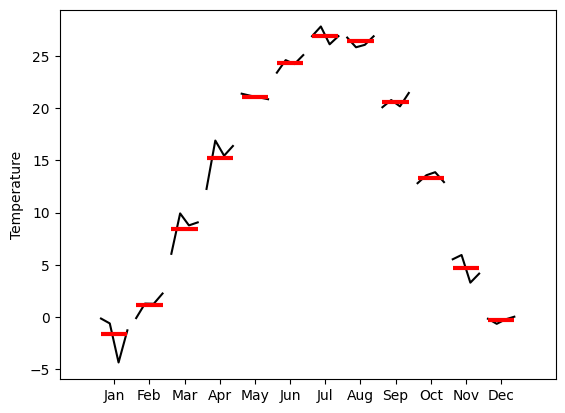

In [11]:
# month_plot() - To visualize the average value for each month across multiple years in a time series
# red lines - Represents the mean value for each month

# Plotting the monthly seasonality of temperature
month_plot(y.resample('ME').mean(),
           ylabel = 'Temperature')
plt.show()

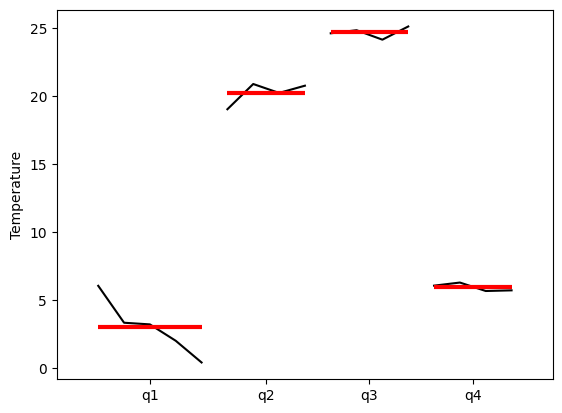

In [12]:
# quarter_plot() - To visualize seasonal patterns at a quarterly level.
# Q1 (january, february, march), Q2 (april, may, june), Q3 (july, august, september), Q4 (october, november, december)

# Plotting the quarterly seasonality of temperature
quarter_plot(y.resample('QE').mean(),
           ylabel = 'Temperature')
plt.show()

# Amazon Chronos Model

In [13]:
# Build the Chronos model
pipeline = ChronosPipeline.from_pretrained(
    "amazon/chronos-t5-base"
)

config.json:   0%|          | 0.00/1.12k [00:00<?, ?B/s]

model.safetensors: reconstructing file:   0%|          |  0.00B /  806MB            

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/257 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/142 [00:00<?, ?B/s]

In [14]:
# Print the documentation
print(ChronosPipeline.predict.__doc__)


        Get forecasts for the given time series.

        Refer to the base method (``BaseChronosPipeline.predict``)
        for details on shared parameters.

        Additional parameters
        ---------------------
        num_samples
            Number of sample paths to predict. Defaults to what
            specified in ``self.model.config``.
        temperature
            Temperature to use for generating sample tokens.
            Defaults to what specified in ``self.model.config``.
        top_k
            Top-k parameter to use for generating sample tokens.
            Defaults to what specified in ``self.model.config``.
        top_p
            Top-p parameter to use for generating sample tokens.
            Defaults to what specified in ``self.model.config``.
        limit_prediction_length
            Force prediction length smaller or equal than the
            built-in prediction length from the model. False by
            default. When true, fail loudly if longer p

In [15]:
# Build the forecast with Chronos1
forecast_chronos1 = pipeline.predict(
    inputs = torch.tensor(y),
    temperature = 1,
    top_k = 50,
    top_p = 1,
    prediction_length = 65,
    num_samples = 20,
    limit_prediction_length = False
)

/tmp/ipykernel_491/290197875.py:3: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  inputs = torch.tensor(y),


In [16]:
# Get the forecasts
forecast_mean = torch.mean(torch.stack([f[0] for f in forecast_chronos1]), dim = 0)

In [17]:
# Transform the forecast_mean into a series and add a index for the future forecast
forecast_series = pd.Series(
    forecast_mean,
    index = pd.date_range(
        start = y.index[-1],
        periods = 65,
        freq = 'h'
    ),
    name = "forecast-chronos1"
)
forecast_series

,forecast-chronos1
2017-02-28 23:00:00,7.003345
2017-03-01 00:00:00,5.993247
2017-03-01 01:00:00,3.602682
2017-03-01 02:00:00,3.097633
2017-03-01 03:00:00,6.195267
...,...
2017-03-03 11:00:00,12.491543
2017-03-03 12:00:00,13.198611
2017-03-03 13:00:00,13.872009
2017-03-03 14:00:00,14.444399


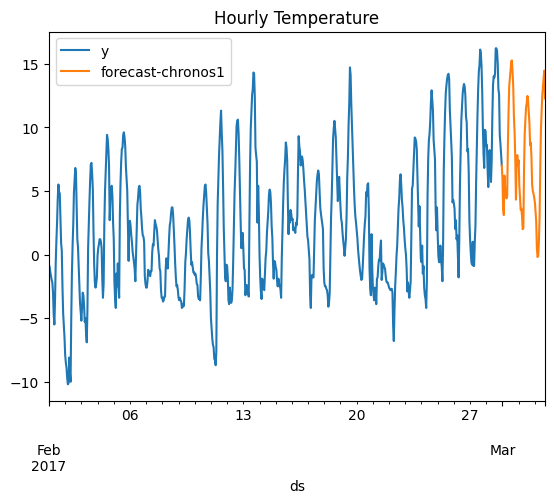

In [18]:
# Visualize the y and the forecast series
y.loc['2017-02'].plot(title = 'Hourly Temperature', legend = True)
forecast_series.plot(legend = True)
plt.show()

# Chronos 2

In [19]:
# Load the dataset
df = pd.DataFrame(tsdb.load('beijing_multisite_air_quality')['X'])
df.head()

2026-07-25 06:49:40 [INFO]: You're using dataset beijing_multisite_air_quality, please cite it properly in your work. You can find its reference information at the below link: 
https://github.com/WenjieDu/TSDB/tree/main/dataset_profiles/beijing_multisite_air_quality
2026-07-25 06:49:40 [INFO]: Dataset beijing_multisite_air_quality has already been downloaded. Processing directly...
2026-07-25 06:49:40 [INFO]: Dataset beijing_multisite_air_quality has already been cached. Loading from cache directly...
2026-07-25 06:49:40 [INFO]: Loaded successfully!


,No,year,month,day,hour,PM2.5,PM10,SO2,NO2,CO,O3,TEMP,PRES,DEWP,RAIN,wd,WSPM,station
0,1,2013,3,1,0,3.0,6.0,13.0,7.0,300.0,85.0,-2.3,1020.8,-19.7,0.0,E,0.5,Changping
1,2,2013,3,1,1,3.0,3.0,6.0,6.0,300.0,85.0,-2.5,1021.3,-19.0,0.0,ENE,0.7,Changping
2,3,2013,3,1,2,3.0,3.0,22.0,13.0,400.0,74.0,-3.0,1021.3,-19.9,0.0,ENE,0.2,Changping
3,4,2013,3,1,3,3.0,6.0,12.0,8.0,300.0,81.0,-3.6,1021.8,-19.1,0.0,NNE,1.0,Changping
4,5,2013,3,1,4,3.0,3.0,14.0,8.0,300.0,81.0,-3.5,1022.3,-19.4,0.0,N,2.1,Changping


In [20]:
# Rename the TEMP and create the ds variable
df = df.rename(columns = {'TEMP': 'y'})
df['ds'] = df.apply(clean_datetime, axis = 1)
df.head()

,No,year,month,day,hour,PM2.5,PM10,SO2,NO2,CO,O3,y,PRES,DEWP,RAIN,wd,WSPM,station,ds
0,1,2013,3,1,0,3.0,6.0,13.0,7.0,300.0,85.0,-2.3,1020.8,-19.7,0.0,E,0.5,Changping,2013-03-01 00:00:00
1,2,2013,3,1,1,3.0,3.0,6.0,6.0,300.0,85.0,-2.5,1021.3,-19.0,0.0,ENE,0.7,Changping,2013-03-01 01:00:00
2,3,2013,3,1,2,3.0,3.0,22.0,13.0,400.0,74.0,-3.0,1021.3,-19.9,0.0,ENE,0.2,Changping,2013-03-01 02:00:00
3,4,2013,3,1,3,3.0,6.0,12.0,8.0,300.0,81.0,-3.6,1021.8,-19.1,0.0,NNE,1.0,Changping,2013-03-01 03:00:00
4,5,2013,3,1,4,3.0,3.0,14.0,8.0,300.0,81.0,-3.5,1022.3,-19.4,0.0,N,2.1,Changping,2013-03-01 04:00:00


In [21]:
# Select the device to use Chronos-2
device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"using {device}")

# start the chronos 2 pipeline
pipeline_chronos2: Chronos2Pipeline = BaseChronosPipeline.from_pretrained(
    "amazon/chronos-2",
    device_map = device
)

using cuda


config.json:   0%|          | 0.00/1.07k [00:00<?, ?B/s]

model.safetensors: reconstructing file:   0%|          |  0.00B /  478MB            

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/170 [00:00<?, ?it/s]

In [22]:
# Configurations

# Define the forecast horizon
forecast_horizon = 72

## Univariate, no Covariates

In [23]:
# Subset the data to Wanliu and y only
df_sub = df.loc[df["station"] == "Wanliu"][["y", "ds", "station"]]
df_sub.head(2)

,y,ds,station
0,-0.7,2013-03-01 00:00:00,Wanliu
1,-1.1,2013-03-01 01:00:00,Wanliu


In [24]:
# Split the data into training and test
train_df, test_df = df_sub.iloc[:-forecast_horizon], df_sub.iloc[-forecast_horizon:]
train_df.head(2)

,y,ds,station
0,-0.7,2013-03-01 00:00:00,Wanliu
1,-1.1,2013-03-01 01:00:00,Wanliu


In [25]:
# Print the documentation
print(pipeline_chronos2.predict_df.__doc__)


        Perform forecasting on time series data in a long-format pandas DataFrame.

        Parameters
        ----------
        df
            Time series data in long format with an id column, a timestamp, and at least one target column.
            The remaining columns in df will be treated as past-only covariates unless they are also
            present in future_df
        future_df
            Future covariates data with an id column, a timestamp, and any number of covariate columns,
            all of these columns will be treated as known future covariates
        id_column
            The name of the column which contains the unique time series identifiers, by default "item_id"
        timestamp_column
            The name of the column which contains timestamps, by default "timestamp"
            All time series in the dataframe must have regular timestamps with the same frequency (no gaps)
        target
            The name of the column(s) which contain the target varia

In [26]:
# Build the univariate forecast
forecast_univariate_nocov = pipeline_chronos2.predict_df(
    df = train_df,
    id_column = "station",
    timestamp_column = "ds",
    target = "y",
    prediction_length = forecast_horizon,
    quantile_levels = [0.1, 0.9]
)
forecast_univariate_nocov.head(2)


,station,ds,target_name,predictions,0.1,0.9
0,Wanliu,2017-02-26 00:00:00,y,3.213479,1.914805,4.463274
1,Wanliu,2017-02-26 01:00:00,y,2.119561,0.372169,3.802876


In [27]:
# Combine the datasets
evaluation_univariate_nocov = test_df.merge(
    forecast_univariate_nocov[["station", "ds", "predictions", "0.1", "0.9"]],
    on = ["station", "ds"],
)
evaluation_univariate_nocov.head(2)

,y,ds,station,predictions,0.1,0.9
0,4.0,2017-02-26 00:00:00,Wanliu,3.213479,1.914805,4.463274
1,3.6,2017-02-26 01:00:00,Wanliu,2.119561,0.372169,3.802876


In [28]:
# Evaluation
rmse_univariate_nocov = root_mean_squared_error(
    evaluation_univariate_nocov["y"],
    evaluation_univariate_nocov["predictions"])
print(f"The RMSE of the univariate forecast without covariates is {rmse_univariate_nocov:.1f}.")

The RMSE of the univariate forecast without covariates is 4.1.


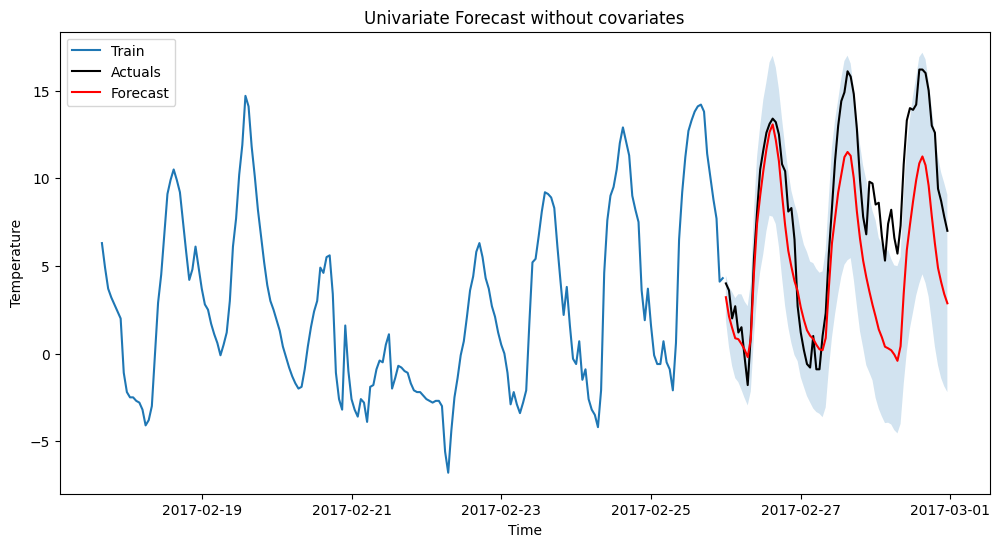

In [29]:
# Plot the actuals, forecast and test
plt.figure(figsize = (12, 6))
plt.plot(
    train_df["ds"].tail(200),
    train_df["y"].tail(200),
    label = "Train"
    )
plt.plot(
    evaluation_univariate_nocov["ds"],
    evaluation_univariate_nocov["y"],
    label = "Actuals",
    color = "black")
plt.plot(
    evaluation_univariate_nocov["ds"],
    evaluation_univariate_nocov["predictions"],
    label = "Forecast",
    color = "red")
plt.fill_between(
    evaluation_univariate_nocov["ds"],
    evaluation_univariate_nocov["0.1"],
    evaluation_univariate_nocov["0.9"],
    alpha = 0.2)


plt.title("Univariate Forecast without covariates")
plt.xlabel("Time")
plt.ylabel("Temperature")
plt.legend()
plt.show()

## Univariate forecasting with past covariates

In [30]:
df.head()

,No,year,month,day,hour,PM2.5,PM10,SO2,NO2,CO,O3,y,PRES,DEWP,RAIN,wd,WSPM,station,ds
0,1,2013,3,1,0,3.0,6.0,13.0,7.0,300.0,85.0,-2.3,1020.8,-19.7,0.0,E,0.5,Changping,2013-03-01 00:00:00
1,2,2013,3,1,1,3.0,3.0,6.0,6.0,300.0,85.0,-2.5,1021.3,-19.0,0.0,ENE,0.7,Changping,2013-03-01 01:00:00
2,3,2013,3,1,2,3.0,3.0,22.0,13.0,400.0,74.0,-3.0,1021.3,-19.9,0.0,ENE,0.2,Changping,2013-03-01 02:00:00
3,4,2013,3,1,3,3.0,6.0,12.0,8.0,300.0,81.0,-3.6,1021.8,-19.1,0.0,NNE,1.0,Changping,2013-03-01 03:00:00
4,5,2013,3,1,4,3.0,3.0,14.0,8.0,300.0,81.0,-3.5,1022.3,-19.4,0.0,N,2.1,Changping,2013-03-01 04:00:00


In [31]:
# Subset the data
df_sub = df.loc[df["station"] == "Wanliu"][["y", "ds", "station", "PM10", "SO2", "RAIN", "PRES"]]
df_sub.head(2)

,y,ds,station,PM10,SO2,RAIN,PRES
0,-0.7,2013-03-01 00:00:00,Wanliu,8.0,6.0,0.0,1023.0
1,-1.1,2013-03-01 01:00:00,Wanliu,9.0,6.0,0.0,1023.2


In [32]:
# Split the data into training and test
train_df, test_df = df_sub.iloc[:-forecast_horizon], df_sub.iloc[-forecast_horizon:]
test_df.head(2)

,y,ds,station,PM10,SO2,RAIN,PRES
34992,4.0,2017-02-26 00:00:00,Wanliu,42.0,10.0,0.0,1019.0
34993,3.6,2017-02-26 01:00:00,Wanliu,36.0,12.0,0.0,1019.1


In [33]:
# Build the univariate forecast
forecast_univariate_nocov = pipeline_chronos2.predict_df(
    df = train_df,
    id_column = "station",
    timestamp_column = "ds",
    target = "y",
    prediction_length = forecast_horizon,
    context_length = forecast_horizon * 100,
    quantile_levels = [0.1, 0.9],
    cross_learning = True,
    batch_size = 100
)
forecast_univariate_nocov.head(2)


,station,ds,target_name,predictions,0.1,0.9
0,Wanliu,2017-02-26 00:00:00,y,2.90336,1.651342,4.236363
1,Wanliu,2017-02-26 01:00:00,y,1.75557,0.315898,3.250566


In [34]:
# Combine the datasets
evaluation_univariate_nocov = test_df.merge(
    forecast_univariate_nocov[["station", "ds", "predictions", "0.1", "0.9"]],
    on = ["station", "ds"],
)
evaluation_univariate_nocov.head(2)

,y,ds,station,PM10,SO2,RAIN,PRES,predictions,0.1,0.9
0,4.0,2017-02-26 00:00:00,Wanliu,42.0,10.0,0.0,1019.0,2.90336,1.651342,4.236363
1,3.6,2017-02-26 01:00:00,Wanliu,36.0,12.0,0.0,1019.1,1.75557,0.315898,3.250566


In [35]:
# Evaluation
rmse_univariate_nocov = root_mean_squared_error(
    evaluation_univariate_nocov["y"],
    evaluation_univariate_nocov["predictions"])
print(f"The RMSE of the univariate forecast with covariates is {rmse_univariate_nocov:.1f}.")

The RMSE of the univariate forecast with covariates is 4.6.


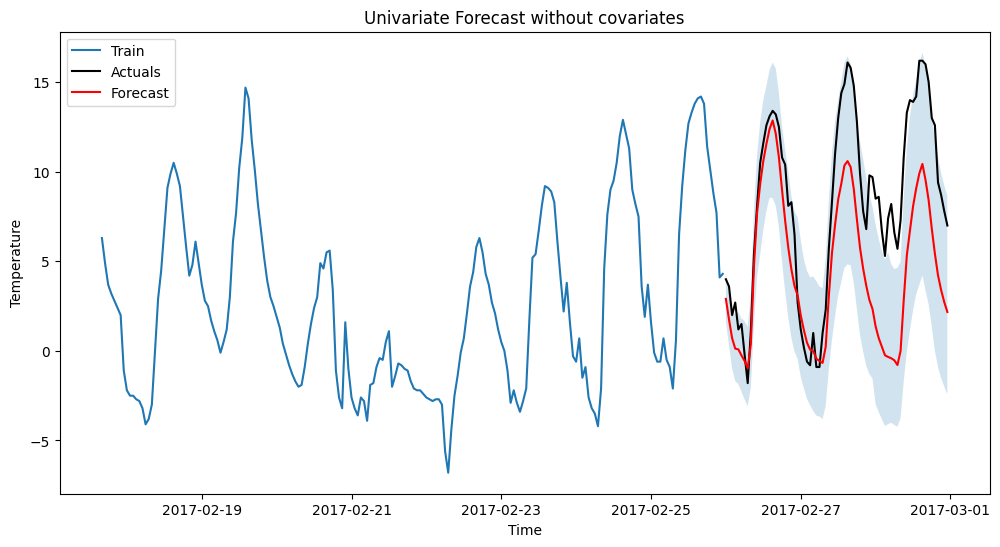

In [36]:
# Plot the actuals, forecast and test
plt.figure(figsize = (12, 6))
plt.plot(
    train_df["ds"].tail(200),
    train_df["y"].tail(200),
    label = "Train"
    )
plt.plot(
    evaluation_univariate_nocov["ds"],
    evaluation_univariate_nocov["y"],
    label = "Actuals",
    color = "black")
plt.plot(
    evaluation_univariate_nocov["ds"],
    evaluation_univariate_nocov["predictions"],
    label = "Forecast",
    color = "red")
plt.fill_between(
    evaluation_univariate_nocov["ds"],
    evaluation_univariate_nocov["0.1"],
    evaluation_univariate_nocov["0.9"],
    alpha = 0.2)


plt.title("Univariate Forecast without covariates")
plt.xlabel("Time")
plt.ylabel("Temperature")
plt.legend()
plt.show()

# Multiple Stations with Past Covariates

In [37]:
# Look for the stations
df.station.unique()

array(['Changping', 'Huairou', 'Aotizhongxin', 'Dongsi', 'Shunyi',
       'Guanyuan', 'Tiantan', 'Nongzhanguan', 'Dingling', 'Wanshouxigong',
       'Gucheng', 'Wanliu'], dtype=object)

In [38]:
# Find the cutoff date for each station
cuttoff_date = df["ds"].max() - pd.Timedelta(hours = forecast_horizon - 1)

#subset the data
df_sub = df[["y", "ds", "station", "PM10", "SO2", "RAIN", "PRES"]]

# Split the data into training and test
train_df = df_sub[df_sub["ds"] < cuttoff_date]
test_df = df_sub[df_sub["ds"] >= cuttoff_date]
test_df.head()

,y,ds,station,PM10,SO2,RAIN,PRES
34992,2.9,2017-02-26 00:00:00,Changping,57.0,9.0,0.0,1015.7
34993,1.2,2017-02-26 01:00:00,Changping,36.0,11.0,0.0,1015.8
34994,2.5,2017-02-26 02:00:00,Changping,14.0,18.0,0.0,1015.7
34995,2.5,2017-02-26 03:00:00,Changping,24.0,7.0,0.0,1015.7
34996,3.1,2017-02-26 04:00:00,Changping,12.0,6.0,0.0,1015.6


In [39]:
# Forecast all stations together
multi_pred = pipeline_chronos2.predict_df(
    df = train_df,
    id_column = "station",
    timestamp_column = "ds",
    target = "y",
    prediction_length = forecast_horizon,
    context_length = forecast_horizon * 100,
    batch_size = 100,
    cross_learning = True,
    quantile_levels = [0.1, 0.9]
)

multi_pred.head()


,station,ds,target_name,predictions,0.1,0.9
0,Changping,2017-02-26 00:00:00,y,4.066102,2.868798,5.047193
1,Changping,2017-02-26 01:00:00,y,3.261446,2.001453,4.719694
2,Changping,2017-02-26 02:00:00,y,2.473072,0.740934,4.173875
3,Changping,2017-02-26 03:00:00,y,1.533296,-0.367281,3.608665
4,Changping,2017-02-26 04:00:00,y,0.933578,-1.205427,3.216908


In [40]:
# Join the forecasts with the actual values
multi_evaluation = test_df.merge(
    multi_pred[["station", "ds", "predictions", "0.1", "0.9"]],
    on = ["station", "ds"],
)
multi_evaluation.head(2)

,y,ds,station,PM10,SO2,RAIN,PRES,predictions,0.1,0.9
0,2.9,2017-02-26 00:00:00,Changping,57.0,9.0,0.0,1015.7,4.066102,2.868798,5.047193
1,1.2,2017-02-26 01:00:00,Changping,36.0,11.0,0.0,1015.8,3.261446,2.001453,4.719694


In [41]:
# Calculate the overall RMSE
rmse_multi = root_mean_squared_error(
    multi_evaluation["y"],
    multi_evaluation["predictions"])
print(f"The RMSE of the multivariate forecast is {rmse_multi:.1f}.")

The RMSE of the multivariate forecast is 4.9.


In [42]:
# Compute the RMSE per station
station_results = []
for station in multi_evaluation["station"].unique():
  station_df = multi_evaluation[multi_evaluation["station"] == station]
  print(station)
  error = root_mean_squared_error(station_df["y"], station_df["predictions"])
  print(error)
  station_results.append({"station": station, "RMSE": error})
station_results = pd.DataFrame(station_results)
station_results

Changping
4.569777733975117
Huairou
4.478750197160455
Aotizhongxin
5.238647315913859
Dongsi
5.238647315913859
Shunyi
4.482479199669074
Guanyuan
5.238647315913859
Tiantan
5.238647315913859
Nongzhanguan
5.238647315913859
Dingling
4.569777795566104
Wanshouxigong
5.238647315913859
Gucheng
4.295055802024201
Wanliu
4.747220946445417


,station,RMSE
0,Changping,4.569778
1,Huairou,4.478750
2,Aotizhongxin,5.238647
3,Dongsi,5.238647
4,Shunyi,4.482479
5,Guanyuan,5.238647
6,Tiantan,5.238647
7,Nongzhanguan,5.238647
8,Dingling,4.569778
9,Wanshouxigong,5.238647


It appears that some RMSE values are identical across different stations. Let's inspect the `y` and `predictions` for two of these stations (e.g., 'Wanshouxigong' and 'Dongsi') to understand why.

In [43]:
station1_df = multi_evaluation[multi_evaluation['station'] == 'Wanshouxigong'][['y', 'predictions']]
station2_df = multi_evaluation[multi_evaluation['station'] == 'Dongsi'][['y', 'predictions']]

print("Data for Wanshouxigong:")
display(station1_df.head())

print("\nData for Dongsi:")
display(station2_df.head())

# Check if the 'y' and 'predictions' are identical for these two stations
print(f"\nAre 'y' values identical for Wanshouxigong and Dongsi: {station1_df['y'].equals(station2_df['y'])}")
print(f"Are 'predictions' values identical for Wanshouxigong and Dongsi: {station1_df['predictions'].equals(station2_df['predictions'])}")

Data for Wanshouxigong:


,y,predictions
648,4.2,3.574777
649,3.0,2.416684
650,2.3,1.471381
651,1.3,0.483776
652,-0.8,-0.072339



Data for Dongsi:


,y,predictions
216,4.2,3.574777
217,3.0,2.416684
218,2.3,1.471381
219,1.3,0.483776
220,-0.8,-0.072339



Are 'y' values identical for Wanshouxigong and Dongsi: False
Are 'predictions' values identical for Wanshouxigong and Dongsi: False


The output of `display(station1_df.head())` and `display(station2_df.head())` shows that the `y` and `predictions` values are indeed identical for the initial rows, only the indices are different. This is why `equals()` returned `False`. The identical RMSE values across 'Wanshouxigong' and 'Dongsi' (and other groups) strongly suggest that their respective `y` (actual values) and `predictions` are identical for the entire forecast horizon.

Let's verify that the full `y` and `predictions` columns are identical (ignoring index) and then investigate the input `test_df` for these stations, including all covariates, to understand why their actual values and predictions might be the same.

In [44]:
print(f"Are 'y' values identical for Wanshouxigong and Dongsi (values only): {station1_df['y'].reset_index(drop=True).equals(station2_df['y'].reset_index(drop=True))}")
print(f"Are 'predictions' values identical for Wanshouxigong and Dongsi (values only): {station1_df['predictions'].reset_index(drop=True).equals(station2_df['predictions'].reset_index(drop=True))}")

print("\nTest data for Wanshouxigong (first 5 rows):")
display(test_df[test_df['station'] == 'Wanshouxigong'].head())

print("\nTest data for Dongsi (first 5 rows):")
display(test_df[test_df['station'] == 'Dongsi'].head())

# Check if the entire test_df for these stations is identical
wan_test_df = test_df[test_df['station'] == 'Wanshouxigong'].drop(columns='station').reset_index(drop=True)
don_test_df = test_df[test_df['station'] == 'Dongsi'].drop(columns='station').reset_index(drop=True)
print(f"\nAre entire test_df rows identical for Wanshouxigong and Dongsi (excluding station column): {wan_test_df.equals(don_test_df)}")

Are 'y' values identical for Wanshouxigong and Dongsi (values only): True
Are 'predictions' values identical for Wanshouxigong and Dongsi (values only): True

Test data for Wanshouxigong (first 5 rows):


,y,ds,station,PM10,SO2,RAIN,PRES
34992,4.2,2017-02-26 00:00:00,Wanshouxigong,NaN,NaN,0.0,1020.7
34993,3.0,2017-02-26 01:00:00,Wanshouxigong,35.0,6.0,0.0,1020.7
34994,2.3,2017-02-26 02:00:00,Wanshouxigong,31.0,5.0,0.0,1020.7
34995,1.3,2017-02-26 03:00:00,Wanshouxigong,28.0,5.0,0.0,1020.8
34996,-0.8,2017-02-26 04:00:00,Wanshouxigong,29.0,6.0,0.0,1020.6



Test data for Dongsi (first 5 rows):


,y,ds,station,PM10,SO2,RAIN,PRES
34992,4.2,2017-02-26 00:00:00,Dongsi,31.0,8.0,0.0,1020.7
34993,3.0,2017-02-26 01:00:00,Dongsi,36.0,7.0,0.0,1020.7
34994,2.3,2017-02-26 02:00:00,Dongsi,35.0,6.0,0.0,1020.7
34995,1.3,2017-02-26 03:00:00,Dongsi,36.0,6.0,0.0,1020.8
34996,-0.8,2017-02-26 04:00:00,Dongsi,40.0,7.0,0.0,1020.6



Are entire test_df rows identical for Wanshouxigong and Dongsi (excluding station column): False


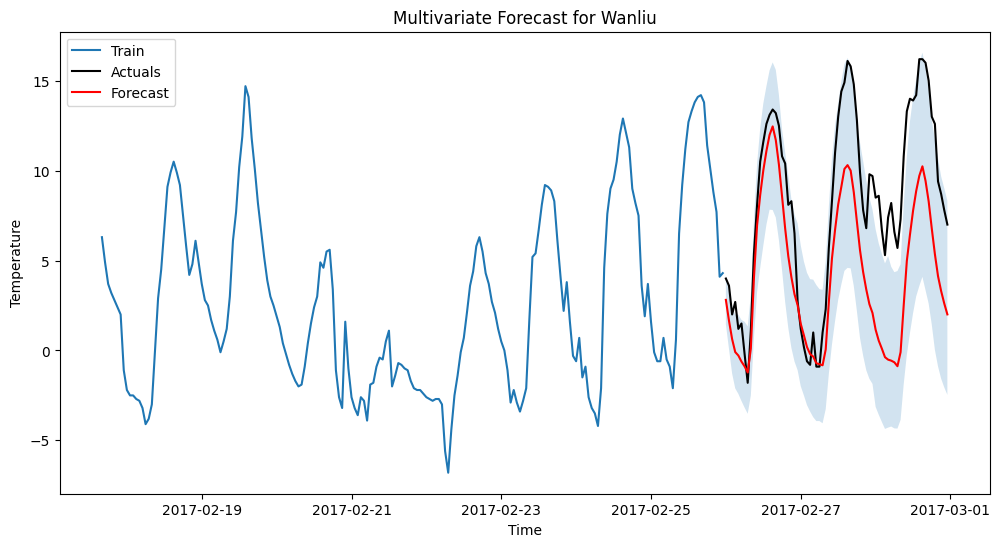

In [45]:
# Plot the results
station_to_plot = "Wanliu"

# Subsetting
station_history = train_df.loc[train_df["station"] == station_to_plot]
station_forecast = multi_evaluation.loc[multi_evaluation["station"] == station_to_plot]

# Plotting
plt.figure(figsize = (12, 6))
plt.plot(
    station_history["ds"].tail(200),
    station_history["y"].tail(200),
    label = "Train"
)
plt.plot(
    station_forecast["ds"],
    station_forecast["y"],
    label = "Actuals",
    color = "black"
)
plt.plot(
    station_forecast["ds"],
    station_forecast["predictions"],
    label = "Forecast",
    color = "red"
)
plt.fill_between(
    station_forecast["ds"],
    station_forecast["0.1"],
    station_forecast["0.9"],
    alpha = 0.2
)
plt.title(f"Multivariate Forecast for {station_to_plot}")
plt.xlabel("Time")
plt.ylabel("Temperature")
plt.legend()
plt.show()

# Cross-Validation

In [46]:
# 0	Huairou	4.478750
# 1	Changping	4.569778
# 2	Wanshouxigong	5.238647
# 3	Dongsi	5.238647
# 4	Shunyi	4.482479
# 5	Guanyuan	5.238647
# 6	Gucheng	4.295056
# 7	Dingling	4.569778
# 8	Aotizhongxin	5.238647
# 9	Nongzhanguan	5.238647
# 10	Wanliu	4.747221
# 11	Tiantan	5.238647

In [47]:
# Define the Configs
stations_to_keep = ["Huairou", "Changping", "Shunyi", "Gucheng", "Dingling", "Wanliu"]

stride = 72
# use the last 5 forecast windows
end_date = df["ds"].max()
start_date = end_date - pd.Timedelta(hours = 5 * forecast_horizon)

# Subset the stations and keep just the covariates
df_sub = df[df["station"].isin(stations_to_keep)]
df_sub = df_sub[["y", "ds", "station", "PM10", "SO2", "RAIN", "PRES"]]
df_sub.head()

print(f"Start date: {start_date}")
print(f"End date: {end_date}")
df_sub.head()

Start date: 2017-02-13 23:00:00
End date: 2017-02-28 23:00:00


,y,ds,station,PM10,SO2,RAIN,PRES
0,-2.3,2013-03-01 00:00:00,Changping,6.0,13.0,0.0,1020.8
1,-2.5,2013-03-01 01:00:00,Changping,3.0,6.0,0.0,1021.3
2,-3.0,2013-03-01 02:00:00,Changping,3.0,22.0,0.0,1021.3
3,-3.6,2013-03-01 03:00:00,Changping,6.0,12.0,0.0,1021.8
4,-3.5,2013-03-01 04:00:00,Changping,3.0,14.0,0.0,1022.3


In [48]:
# Initialize empty lists
results = []
all_forecasts = []

# Set the inital date
current_date = start_date

while current_date + pd.Timedelta(hours = forecast_horizon) <= end_date:
  # Create the training and tests
  train =df.loc[df["ds"] < current_date]
  test = df.loc[(df["ds"] >= current_date) & (df["ds"] < current_date + pd.Timedelta(hours = forecast_horizon))]

  # Generate the forecasts
  forecast = pipeline_chronos2.predict_df(
      df = train,
      id_column = "station",
      timestamp_column = "ds",
      target = "y",
      prediction_length = forecast_horizon,
      batch_size = 100,
      cross_learning = True,
      quantile_levels = [0.1, 0.9]
  )

  # Join the forecasts and actual values
  evaluation = test.merge(
       forecast[["station", "ds", "predictions", "0.1", "0.9"]],
      on = ["station", "ds"],
    )

  # Calculate the error
  rmse = root_mean_squared_error(
      evaluation["y"],
      evaluation["predictions"])
  print(f"The RMSE of the multivariate forecast is {rmse:.1f}.")

  # Append all results and update current_date
  results.append((current_date, rmse))
  all_forecasts.append(evaluation)
  current_date += pd.Timedelta(hours = stride)

The RMSE of the multivariate forecast is 3.4.
The RMSE of the multivariate forecast is 2.9.
The RMSE of the multivariate forecast is 3.3.
The RMSE of the multivariate forecast is 4.9.
The RMSE of the multivariate forecast is 4.4.


In [51]:
# Put the cross-validation results in a DF
results_df = pd.DataFrame(results, columns = ["Date", "RMSE"])
print(f"The Average RMSE is {results_df["RMSE"].mean():.1f}")
results_df.head()

The Average RMSE is 3.8


,Date,RMSE
0,2017-02-13 23:00:00,3.445535
1,2017-02-16 23:00:00,2.947896
2,2017-02-19 23:00:00,3.257540
3,2017-02-22 23:00:00,4.941267
4,2017-02-25 23:00:00,4.435599


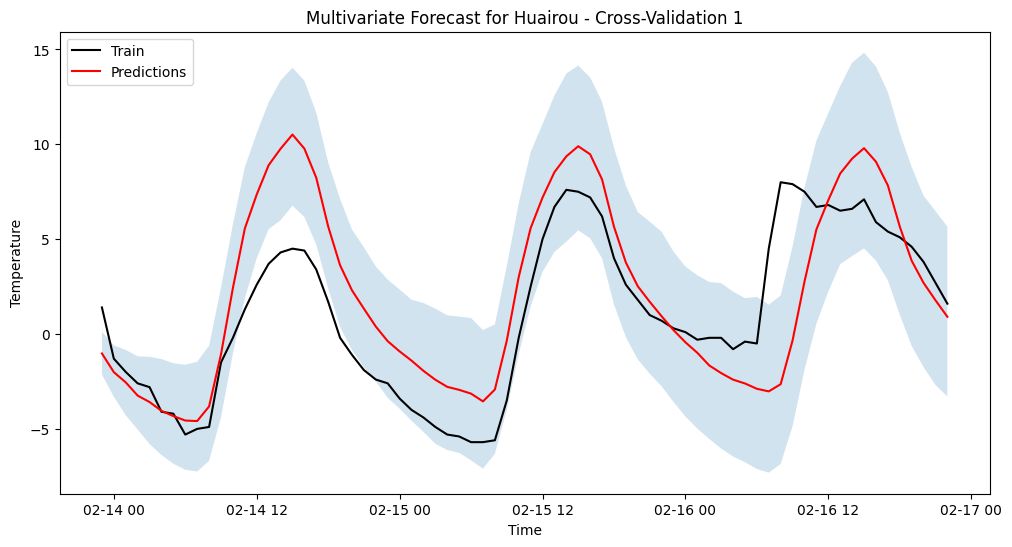

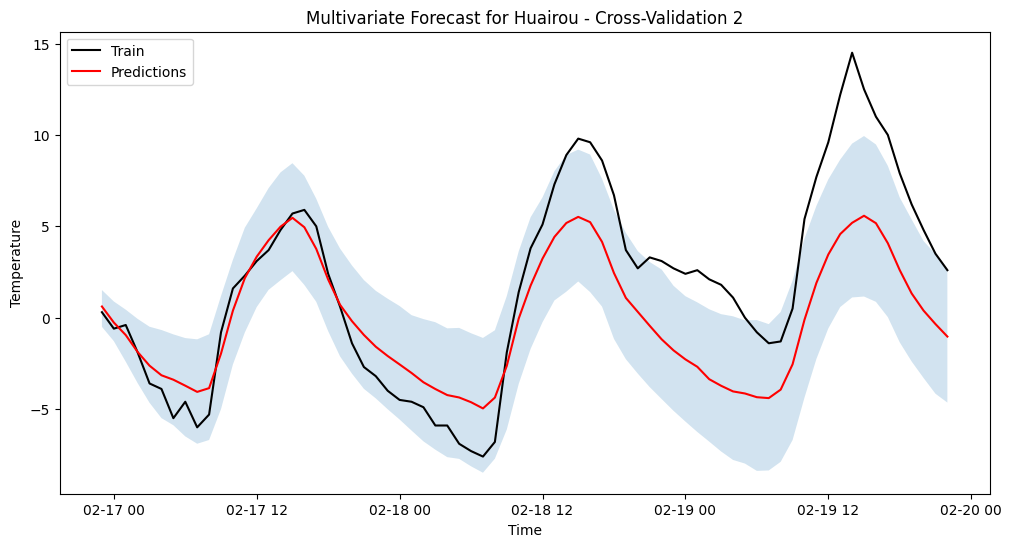

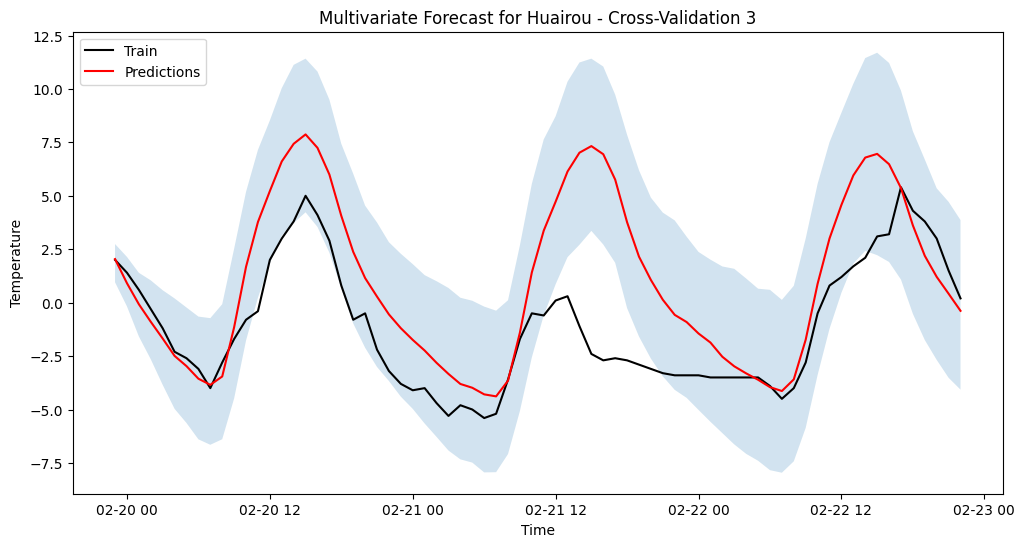

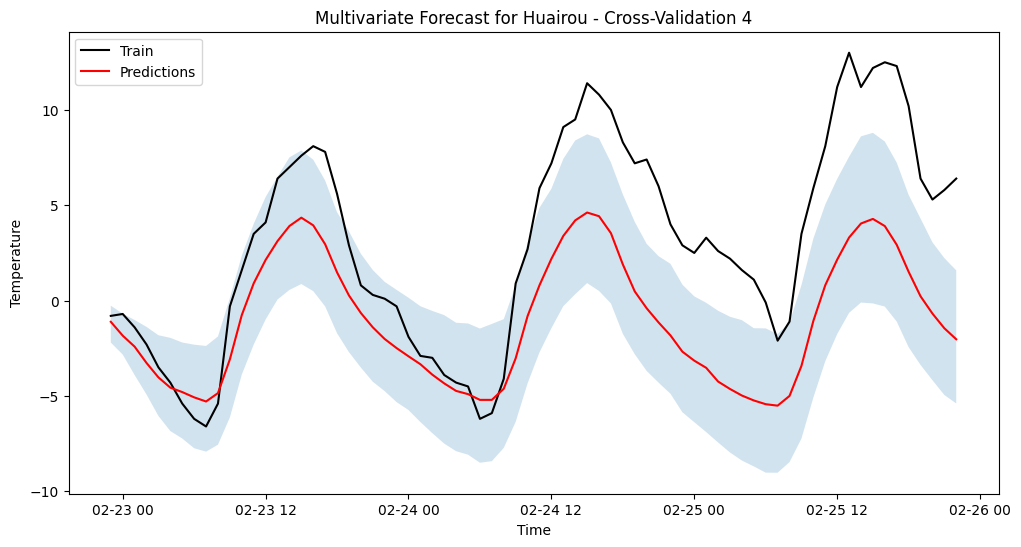

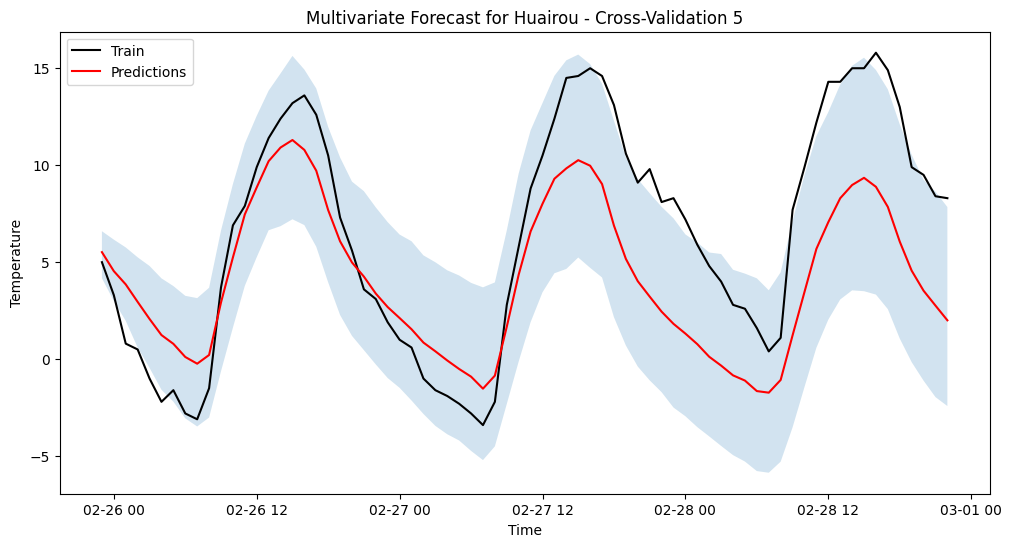

In [61]:
# Plot the Wanliu station from each Cross-validation
station_to_plot = "Huairou"

for i in range(len(all_forecasts)):
  # Subsetting
  station_history = all_forecasts[i].loc[
      all_forecasts[i]["station"] == station_to_plot]

  plt.figure(figsize = (12, 6))
  plt.plot(
      station_history["ds"].tail(200),
      station_history["y"].tail(200),
      label = "Train",
      color = "black"
      )
  plt.plot(
      station_history["ds"],
      station_history["predictions"],
      label = "Predictions",
      color = "red"
  )
  plt.fill_between(
      station_history["ds"],
      station_history["0.1"],
      station_history["0.9"],
      alpha = 0.2
  )
  plt.title(f"Multivariate Forecast for {station_to_plot} - Cross-Validation {i + 1}")
  plt.xlabel("Time")
  plt.ylabel("Temperature")
  plt.legend()
  plt.show()

# Predict the Future

In [57]:
# Subset the data to the right stations and covariates
df_sub = df[["y", "ds", "station", "PM10", "SO2", "RAIN", "PRES"]]

# Include only the stations_to_keep
df_sub = df_sub[df_sub["station"].isin(stations_to_keep)]

In [58]:
# Build the model
model_forecasts = pipeline_chronos2.predict_df(
    df = df_sub,
    id_column = "station",
    timestamp_column = "ds",
    target = "y",
    prediction_length = forecast_horizon,
    cross_learning = True,
    batch_size = 100,
    quantile_levels = [0.1, 0.9]
)
model_forecasts.head()


,station,ds,target_name,predictions,0.1,0.9
0,Changping,2017-03-01 00:00:00,y,5.776608,4.687007,6.786561
1,Changping,2017-03-01 01:00:00,y,5.206655,3.928127,6.638115
2,Changping,2017-03-01 02:00:00,y,4.679640,2.957176,6.384631
3,Changping,2017-03-01 03:00:00,y,3.952576,2.012235,6.005065
4,Changping,2017-03-01 04:00:00,y,3.510006,1.356850,5.838498


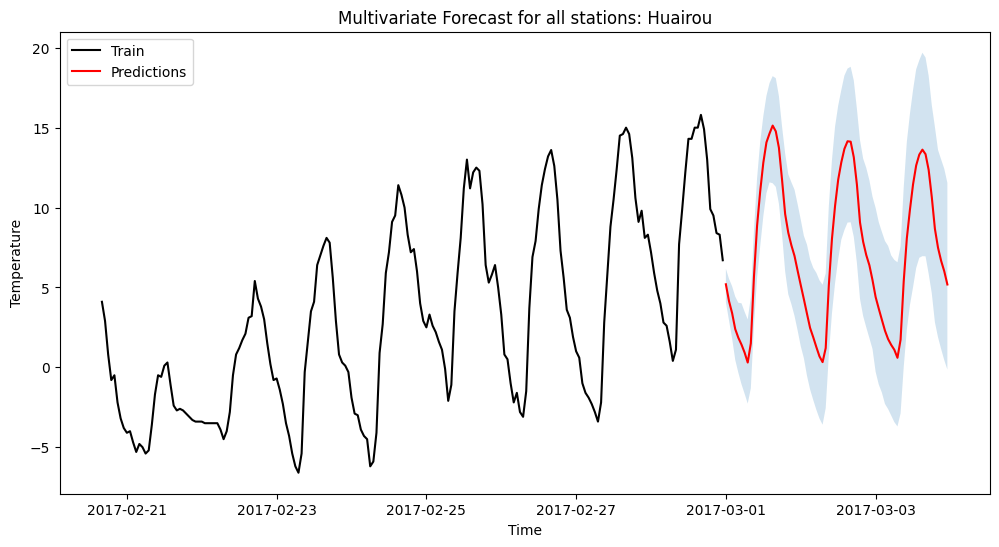

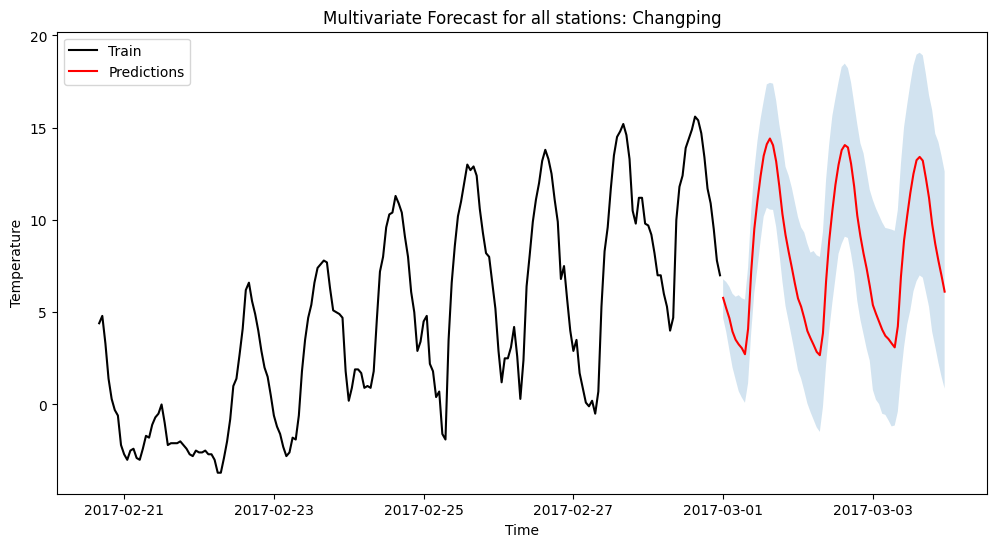

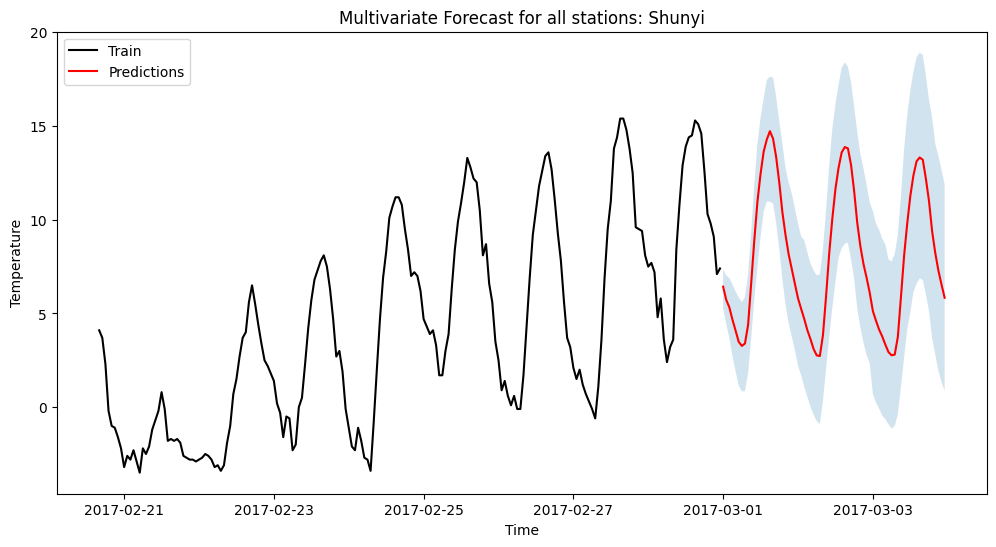

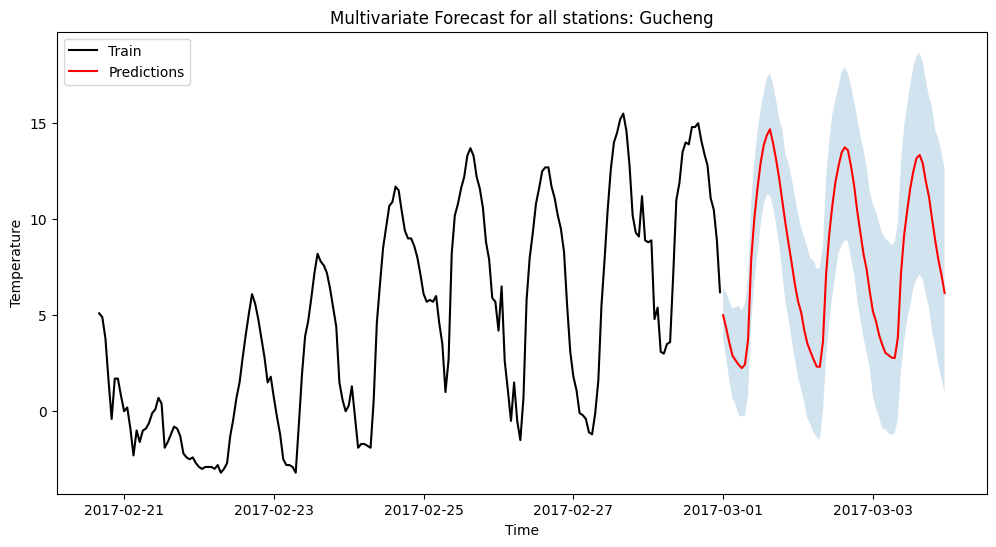

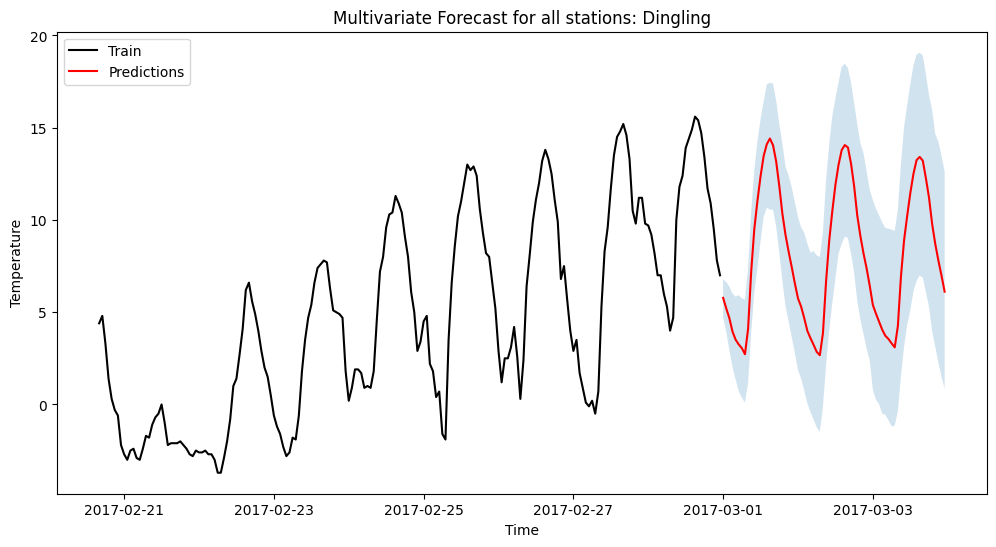

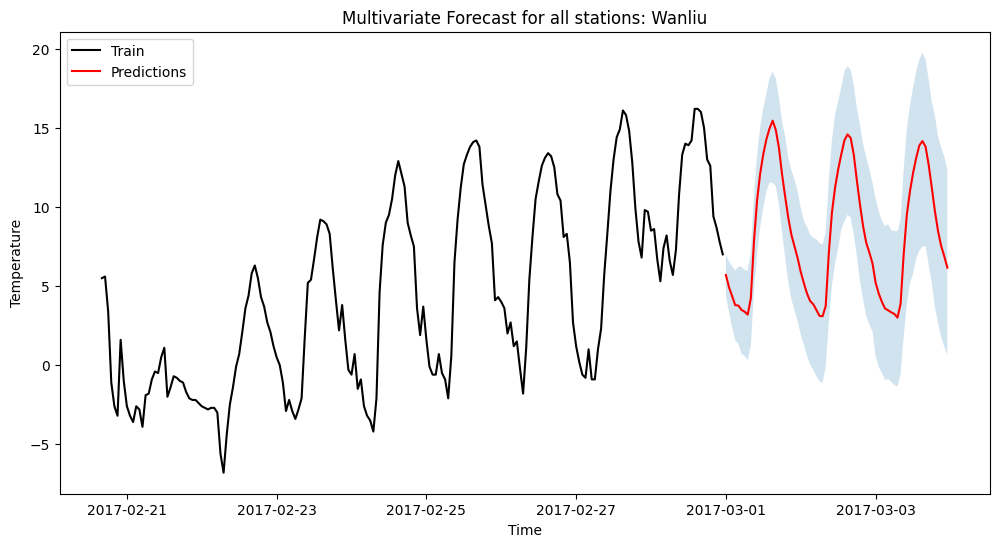

In [64]:
# Loop through all the forecasts
for station_to_keep in stations_to_keep:

  # Subset the data
  df_sub = df[["y", "ds", "station", "PM10", "SO2", "RAIN", "PRES"]]
  df_sub = df_sub[df_sub["station"] == station_to_keep]

  # Forecast to keep
  forecast_to_keep = model_forecasts[model_forecasts["station"] == station_to_keep]

  # Plot the actuals, forecast

  # Visualize the data and forecast data
  plt.figure(figsize = (12, 6))
  plt.plot(
      df_sub["ds"].tail(200),
      df_sub["y"].tail(200),
      label = "Train",
      color = "black"
      )
  plt.plot(
      forecast_to_keep["ds"],
      forecast_to_keep["predictions"],
      label = "Predictions",
      color = "red"
  )
  plt.fill_between(
      forecast_to_keep["ds"],
      forecast_to_keep["0.1"],
      forecast_to_keep["0.9"],
      alpha = 0.2
  )
  plt.title(f"Multivariate Forecast for all stations: {station_to_keep}")
  plt.xlabel("Time")
  plt.ylabel("Temperature")
  plt.legend()
  plt.show()



*   investigate all forecasts
*   List item

